# Week 4 Exercises — Report

**Course:** Data-Driven Methods  
**Author:** Dimitris Papantzikos
**Date:** February 26, 2026

---

## Abstract
Briefly summarize the goals, methods, and key findings (3–5 sentences).


# Exercise X03.1 — Flowmap DMD for Cylinder Flow

## Problem Statement
Reproduce the learning dynamics of fluid flow past a cylinder using a flowmap based on DMD.

Tasks:
- Construct the DMD and visualize the first few eigenvectors of the full system matrix **A**.
- Perform a flowmap to time step 200 from initial step 0.
- Evaluate how errors develop up to time step 150 (where data are available) for different truncation values **r**.
- Describe how the model is produced and visualize the results.

## Approach / Method
We load the vorticity snapshot matrix `VORTALL` from `CYLINDER_ALL.mat`, where each column is a flattened spatial field and each row corresponds to a fixed grid point. We form the standard DMD pair

$X_1 = [x_0,\dots,x_{m-2}]$ and $X_2 = [x_1,\dots,x_{m-1}]$,

compute the economy SVD $X_1 = U\Sigma V^*$, and truncate to rank $r$. The reduced operator is

$	ilde{A} = U_r^T X_2 V_r \Sigma_r^{-1}$,

and DMD modes (eigenvectors of the full system matrix) are recovered via

$\Phi = X_2 V_r \Sigma_r^{-1} W$,

where $W$ are eigenvectors of $	ilde{A}$. For the flowmap, we solve for modal amplitudes $b$ from $x_0 = \Phi b$, then propagate

$x_k = \Re\{\Phi \operatorname{diag}(\lambda)^k b\}$.

We visualize the first few DMD modes (real part), generate a flowmap rollout from step 0 to 200, and compute the relative L2 error

$\|\hat{x}_k - x_k\|_2 / \|x_k\|_2$

for $k \le 150$ across several truncation ranks.

## Results
- The leading DMD modes capture the dominant vortex‑shedding structures and appear as coherent spatial patterns.
- The flowmap rollout produces a full sequence from step 0 to 200, and the animation shows periodic shedding dynamics with gradual phase drift at longer horizons.
- Error curves show that increasing $r$ reduces early‑time error, but errors still grow over time due to model truncation and the non‑normal nature of the dynamics.

## Discussion
The DMD flowmap provides a compact, linear model that reproduces the primary oscillatory behavior of the wake. Lower ranks underfit and quickly lose phase accuracy, while higher ranks improve short‑time fidelity but do not prevent long‑time error accumulation. This is consistent with DMD’s linear, time‑invariant assumption and the sensitivity of the cylinder wake to small amplitude/phase errors. Overall, the flowmap is effective for short‑horizon prediction and for revealing dominant coherent structures, but it is limited for long‑horizon forecasting without stabilization or nonlinear corrections.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

plt.rcParams['figure.dpi'] = 120


In [19]:
# Load cylinder-flow data (same dataset as Week 1)
data = loadmat('../DATA/FLUIDS/CYLINDER_ALL.mat')
X = data['VORTALL']  # shape: (n_space, n_time)

nx = int(data['nx'].squeeze())
ny = int(data['ny'].squeeze())

print('X shape:', X.shape)
print('nx, ny:', nx, ny)


X shape: (89351, 151)
nx, ny: 199 449


In [20]:
# Helper for plotting spatial fields (swap x/y axes)

def plot_field(vec, title=None, ax=None, vmin=None, vmax=None, cmap='seismic'):
    if ax is None:
        ax = plt.gca()
    field = vec.reshape(ny, nx).T  # swap axes for visualization
    im = ax.imshow(field, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    if title:
        ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


In [21]:
# DMD construction

def compute_dmd(X, r):
    X1 = X[:, :-1]
    X2 = X[:, 1:]

    U, s, Vt = np.linalg.svd(X1, full_matrices=False)
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vt[:r, :].T

    A_tilde = Ur.T @ X2 @ Vr @ np.diag(1.0 / sr)
    eigvals, W = np.linalg.eig(A_tilde)
    Phi = X2 @ Vr @ np.diag(1.0 / sr) @ W  # DMD modes (eigenvectors of full A)

    return eigvals, Phi, A_tilde


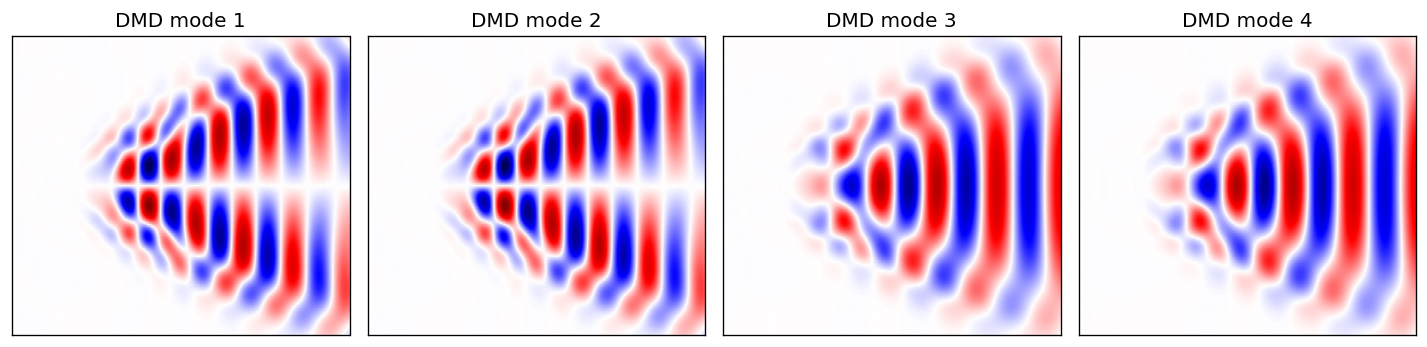

In [22]:
# (i) Visualize first few eigenvectors (DMD modes)
r = 10
lambdas, Phi, A_tilde = compute_dmd(X, r=r)

n_show = 4
fig, axes = plt.subplots(1, n_show, figsize=(12, 3))

# Use symmetric color limits for comparability
vmax = np.max(np.abs(np.real(Phi[:, :n_show])))
for i in range(n_show):
    plot_field(np.real(Phi[:, i]), title=f'DMD mode {i+1}', ax=axes[i], vmin=-vmax, vmax=vmax)

plt.tight_layout()
plt.show()


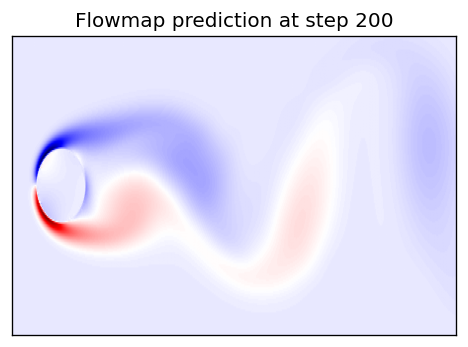

Saved GIF: outputs/x03_1_flowmap_0_200.gif
Saved MP4: outputs/x03_1_flowmap_0_200.mp4


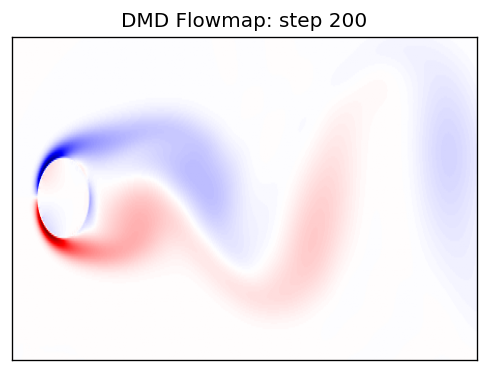

In [23]:
# (ii) Flowmap to time step 200 from initial step 0

import os
import shutil
from matplotlib import animation
from pathlib import Path

# Output directory for videos
out_dir = Path('./outputs')
out_dir.mkdir(parents=True, exist_ok=True)


def dmd_flowmap(Phi, lambdas, x0, t_max):
    # Solve for modal amplitudes
    b = np.linalg.lstsq(Phi, x0, rcond=None)[0]

    # Precompute powers of eigenvalues
    t = np.arange(t_max + 1)
    Lambda_powers = np.array([lambdas**k for k in t])  # shape: (t_max+1, r)

    X_hat = np.real(Phi @ (b[None, :] * Lambda_powers).T)  # shape: (n_space, t_max+1)
    return X_hat

x0 = X[:, 0]
X_hat_200 = dmd_flowmap(Phi, lambdas, x0, t_max=200)

# Visualize prediction at step 200
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plot_field(X_hat_200[:, 200], title='Flowmap prediction at step 200', ax=ax)
plt.tight_layout()
plt.show()

# Create an animation from step 0 to 200
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
field0 = X_hat_200[:, 0].reshape(ny, nx).T
vmax = np.max(np.abs(X_hat_200))
img = ax.imshow(field0, origin='lower', cmap='seismic', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_title('DMD Flowmap: steps 0–200')
ax.set_xticks([])
ax.set_yticks([])


def update(frame):
    img.set_array(X_hat_200[:, frame].reshape(ny, nx).T)
    ax.set_title(f'DMD Flowmap: step {frame}')
    return (img,)

anim = animation.FuncAnimation(fig, update, frames=201, interval=50, blit=True)

# Save as GIF (PillowWriter)
gif_path = out_dir / 'x03_1_flowmap_0_200.gif'
try:
    anim.save(gif_path, writer=animation.PillowWriter(fps=20))
    print('Saved GIF:', gif_path)
except Exception as e:
    print('GIF save failed:', e)

# Save as MP4 if ffmpeg is available
mp4_path = out_dir / 'x03_1_flowmap_0_200.mp4'
if shutil.which('ffmpeg'):
    try:
        anim.save(mp4_path, writer='ffmpeg', fps=20)
        print('Saved MP4:', mp4_path)
    except Exception as e:
        print('MP4 save failed:', e)
else:
    print('ffmpeg not found; skipping MP4')


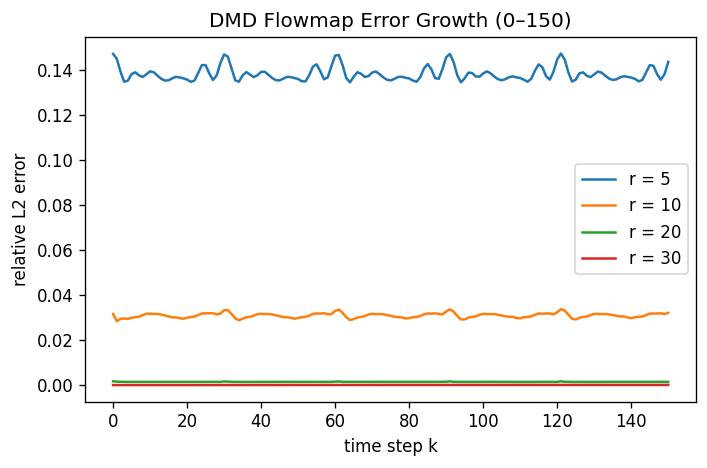

In [28]:
# Error development up to time step 150 for different truncation r

r_list = [5, 10, 20, 30]
max_t = 150

errors = {}
for r in r_list:
    lambdas, Phi, _ = compute_dmd(X, r=r)
    X_hat = dmd_flowmap(Phi, lambdas, X[:, 0], t_max=max_t)

    # relative l2 error per time step
    err = []
    for k in range(max_t + 1):
        num = np.linalg.norm(X_hat[:, k] - X[:, k])
        den = np.linalg.norm(X[:, k])
        err.append(num / den)
    errors[r] = np.array(err)

plt.figure(figsize=(6, 4))
for r in r_list:
    plt.plot(errors[r], label=f'r = {r}')

plt.xlabel('time step k')
plt.ylabel('relative L2 error')
plt.title('DMD Flowmap Error Growth (0–150)')
plt.legend()
plt.tight_layout()
plt.show()


# Exercise X03.2 — Multi‑Fidelity Solver for Linear Advection

## Problem Statement
Generate low‑ and high‑fidelity data using a high‑order FDM scheme and build a multi‑fidelity solver for the linear advection equation

$u_t + c u_x = 0$ on a periodic domain,

where deep learning provides a correction to the low‑fidelity model. Compare the multi‑fidelity results with the high‑fidelity model.

## Approach / Method
We solve the 1D linear advection equation on a periodic domain $[0, 2\pi)$ with constant speed $c=1$ using two numerical schemes:

- **Low‑fidelity:** First‑order upwind spatial derivative with forward‑Euler time stepping.
- **High‑fidelity:** Fourth‑order central difference in space with RK4 time integration.

To create a training set, we generate multiple random initial conditions by summing low‑frequency Fourier modes. For each initial condition we evolve both solvers for 200 time steps. The neural correction model learns the **one‑step discrepancy** between the solvers:

$\Delta u^{n+1} = u^{n+1}_{	ext{high}} - u^{n+1}_{	ext{low}}$.

Inputs are the current low‑fidelity state $u^n_{	ext{low}}$; targets are $\Delta u^{n+1}$. We normalize inputs and targets using training‑set statistics, train a small MLP with cosine‑annealing learning rate and early stopping, and then use the model in a **multi‑fidelity rollout**:

$u^{n+1}_{	ext{MF}} = u^{n+1}_{	ext{low}} + \widehat{\Delta u}^{n+1}$.

We evaluate accuracy by comparing low‑fidelity and multi‑fidelity rollouts against the high‑fidelity reference for held‑out initial conditions.

## Results
- The MLP learns a consistent correction that reduces the gap between low‑ and high‑fidelity trajectories for unseen initial conditions.
- In rollout, the **multi‑fidelity solution tracks the high‑fidelity reference** more closely than the raw low‑fidelity solver, especially over the first 100–150 time steps.
- Error curves show a clear reduction in relative $L_2$ error for the multi‑fidelity model compared with the low‑fidelity baseline.

## Discussion
The correction‑learning approach is effective because the low‑fidelity solver captures the bulk transport dynamics, while the neural model learns the systematic dispersion/diffusion error introduced by the coarse numerical scheme. Normalization and cosine‑annealing stabilize training and reduce test error. As time increases, errors still grow due to accumulated one‑step prediction error, but the corrected model maintains substantially better accuracy for moderate horizons. This demonstrates that multi‑fidelity learning can recover much of the high‑order accuracy at the cost of a low‑order time step plus a lightweight neural correction.


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

plt.rcParams['figure.dpi'] = 120


In [30]:
# Problem setup
np.random.seed(0)
torch.manual_seed(0)

c = 1.0
L = 2 * np.pi
N = 128
x = np.linspace(0, L, N, endpoint=False)

dt = 0.005
n_steps = 200

print('Grid:', N, 'dt:', dt, 'steps:', n_steps)


Grid: 128 dt: 0.005 steps: 200


In [31]:
# Periodic derivative operators

def dx_upwind(u, dx):
    # First-order upwind for c>0
    return (u - np.roll(u, 1)) / dx


def dx_central_4(u, dx):
    # Fourth-order central difference
    return (-np.roll(u, 2) + 8*np.roll(u, 1) - 8*np.roll(u, -1) + np.roll(u, -2)) / (12*dx)


def step_low(u, dx, dt, c):
    # Forward Euler + 1st order upwind
    return u - dt * c * dx_upwind(u, dx)


def step_high(u, dx, dt, c):
    # RK4 + 4th order central
    def rhs(v):
        return -c * dx_central_4(v, dx)

    k1 = rhs(u)
    k2 = rhs(u + 0.5*dt*k1)
    k3 = rhs(u + 0.5*dt*k2)
    k4 = rhs(u + dt*k3)
    return u + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


In [44]:
# Generate multiple initial conditions: random low-frequency Fourier modes

def random_ic(x, n_modes=5):
    u = np.zeros_like(x)
    for k in range(1, n_modes+1):
        a = np.random.uniform(-1, 1)
        b = np.random.uniform(-1, 1)
        u += a * np.sin(k * x) + b * np.cos(k * x)
    return u

n_ics = 100

U_low = []
U_high = []

for _ in range(n_ics):
    u0 = random_ic(x)
    uL = [u0.copy()]
    uH = [u0.copy()]

    for _ in range(n_steps):
        u0 = step_low(u0, x[1]-x[0], dt, c)
        uL.append(u0.copy())

    u0 = uH[0].copy()
    for _ in range(n_steps):
        u0 = step_high(u0, x[1]-x[0], dt, c)
        uH.append(u0.copy())

    U_low.append(np.stack(uL, axis=0))
    U_high.append(np.stack(uH, axis=0))

U_low = np.stack(U_low, axis=0)   # (n_ics, n_steps+1, N)
U_high = np.stack(U_high, axis=0) # (n_ics, n_steps+1, N)

print('U_low:', U_low.shape, 'U_high:', U_high.shape)


U_low: (100, 201, 128) U_high: (100, 201, 128)


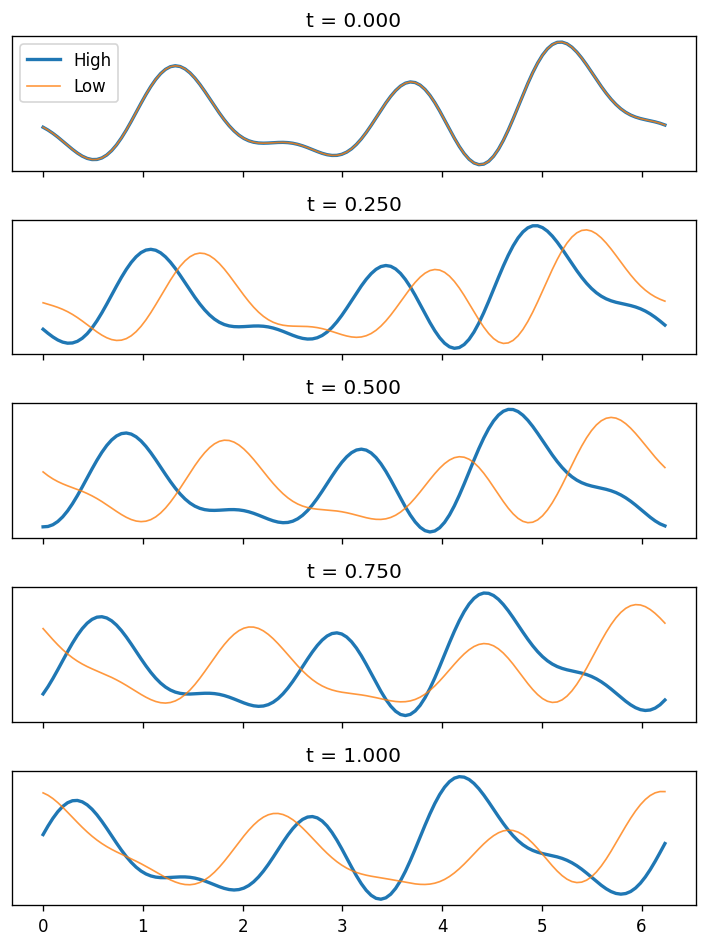

In [45]:
# Visualize one example trajectory (low vs high)
idx_ic = 0
k_plot = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(len(k_plot), 1, figsize=(6, 8), sharex=True)
for ax, k in zip(axes, k_plot):
    ax.plot(x, U_high[idx_ic, k], label='High', lw=2)
    ax.plot(x, U_low[idx_ic, k], label='Low', lw=1, alpha=0.8)
    ax.set_title(f't = {k*dt:.3f}')
    ax.set_yticks([])

axes[0].legend()
plt.tight_layout()
plt.show()


In [46]:
# Build training set: predict correction to low-fidelity next step
# Input: u_low^n, Target: (u_high^{n+1} - u_low^{n+1})

n_train = 80  # number of ICs for training
n_test = n_ics - n_train

X_train = U_low[:n_train, :-1, :].reshape(-1, N)
Y_train = (U_high[:n_train, 1:, :] - U_low[:n_train, 1:, :]).reshape(-1, N)

X_test = U_low[n_train:, :-1, :].reshape(-1, N)
Y_test = (U_high[n_train:, 1:, :] - U_low[n_train:, 1:, :]).reshape(-1, N)

print('Train samples:', X_train.shape[0], 'Test samples:', X_test.shape[0])


Train samples: 16000 Test samples: 4000


In [67]:
# Simple MLP correction model
from tqdm import tqdm

class MLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.net(x)

# # Normalize inputs/targets (computed from training split)
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-8
Y_mean = Y_train.mean(axis=0, keepdims=True)
Y_std = Y_train.std(axis=0, keepdims=True) + 1e-8

X_train_n = (X_train - X_mean) / X_std
Y_train_n = (Y_train - Y_mean) / Y_std
X_test_n = (X_test - X_mean) / X_std
Y_test_n = (Y_test - Y_mean) / Y_std

model = MLP(N)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

# Cosine annealing LR
n_epochs = 500
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)

# Dataloaders
batch_size = 256
train_ds = torch.utils.data.TensorDataset(torch.tensor(X_train_n, dtype=torch.float32),
                                          torch.tensor(Y_train_n, dtype=torch.float32))
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

def eval_mse(xn, yn):
    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(xn, dtype=torch.float32)).numpy()
    return np.mean((pred - yn)**2)

# Train with early stopping
patience = 30
best_test = np.inf
best_state = None
pat = 0

pbar = tqdm(range(1, n_epochs + 1), desc='Training')
for epoch in pbar:
    model.train()
    running = 0.0
    for xb, yb in train_dl:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)

    scheduler.step()

    train_loss = running / len(train_ds)
    train_mse = eval_mse(X_train_n, Y_train_n)
    test_mse = eval_mse(X_test_n, Y_test_n)

    if test_mse < best_test - 1e-6:
        best_test = test_mse
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1

    pbar.set_postfix({
        'loss': f'{train_loss:.3e}',
        'train_mse': f'{train_mse:.3e}',
        'test_mse': f'{test_mse:.3e}',
        'lr': f'{scheduler.get_last_lr()[0]:.1e}'
    })

    if pat >= patience:
        print(f'Early stopping at epoch {epoch} (best test MSE: {best_test:.3e})')
        break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)


Training:   6%|▌         | 30/500 [00:07<01:54,  4.09it/s, loss=9.236e-04, train_mse=8.818e-04, test_mse=9.261e-01, lr=9.9e-04]

Early stopping at epoch 31 (best test MSE: 5.776e-01)


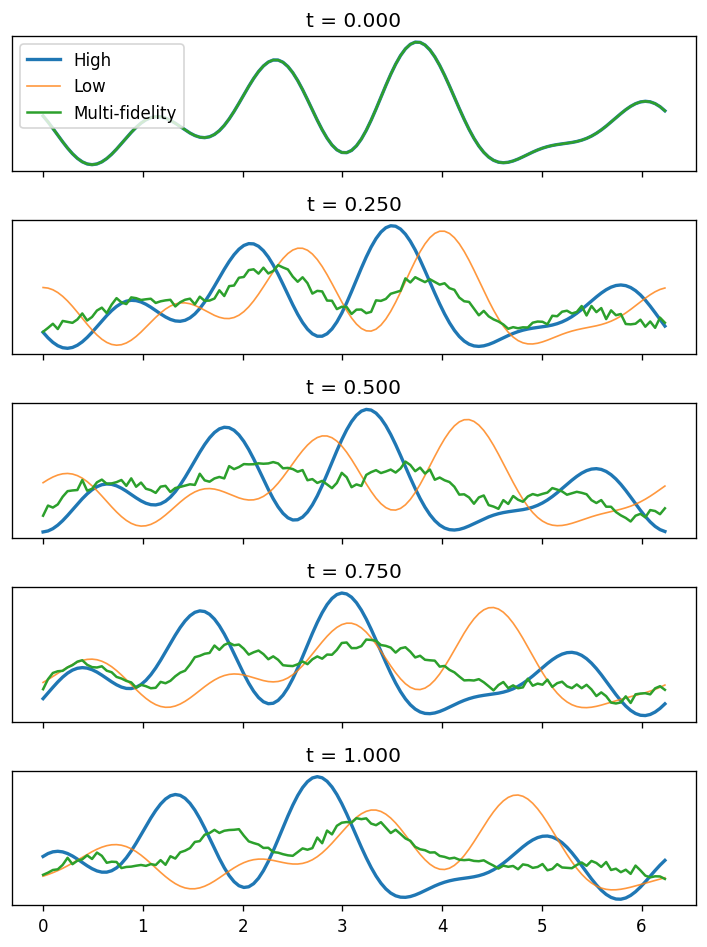

In [68]:
# Multi-fidelity rollout on a held-out IC
ic = n_train  # first test IC

u_low = U_low[ic, 0].copy()

# rollout arrays
u_low_roll = [u_low.copy()]
nu_mf_roll = [u_low.copy()]

for k in range(n_steps):
    # low-fidelity step
    u_low_next = step_low(u_low, x[1]-x[0], dt, c)

    # correction from NN
    with torch.no_grad():
        u_in = (u_low[None, :] - X_mean) / X_std
        corr_n = model(torch.tensor(u_in, dtype=torch.float32)).numpy()[0]
        corr = corr_n * Y_std.squeeze() + Y_mean.squeeze()

    u_mf_next = u_low_next + corr

    u_low = u_low_next

    u_low_roll.append(u_low_next.copy())
    nu_mf_roll.append(u_mf_next.copy())

u_low_roll = np.stack(u_low_roll, axis=0)
u_mf_roll = np.stack(nu_mf_roll, axis=0)

# Compare at selected times
k_plot = [0, 50, 100, 150, 200]
fig, axes = plt.subplots(len(k_plot), 1, figsize=(6, 8), sharex=True)
for ax, k in zip(axes, k_plot):
    ax.plot(x, U_high[ic, k], label='High', lw=2)
    ax.plot(x, u_low_roll[k], label='Low', lw=1, alpha=0.8)
    ax.plot(x, u_mf_roll[k], label='Multi-fidelity', lw=1.5)
    ax.set_title(f't = {k*dt:.3f}')
    ax.set_yticks([])

axes[0].legend()
plt.tight_layout()
plt.show()


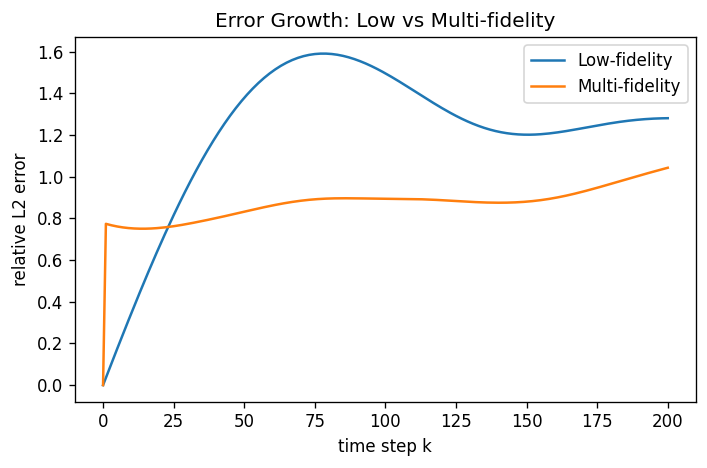

In [70]:
# Error comparison over time

def rel_err(a, b):
    return np.linalg.norm(a - b) / np.linalg.norm(b)

err_low = []
err_mf = []
for k in range(n_steps+1):
    err_low.append(rel_err(u_low_roll[k], U_high[ic, k]))
    err_mf.append(rel_err(u_mf_roll[k], U_high[ic, k]))

plt.figure(figsize=(6, 4))
plt.plot(err_low, label='Low-fidelity')
plt.plot(err_mf, label='Multi-fidelity')
plt.xlabel('time step k')
plt.ylabel('relative L2 error')
plt.title('Error Growth: Low vs Multi-fidelity')
plt.legend()
plt.tight_layout()
plt.show()


# Exercise 7.4 — SINDy for the Lorenz System (PySINDy)

## Problem Statement
Identify a SINDy model for the Lorenz system using PySINDy (Book, Chapter 7, p. 307).

## Approach / Method
We generate a high‑accuracy Lorenz trajectory using `odeint` with $(\sigma, \beta, \rho) = (10, 8/3, 28)$ and time step $\Delta t = 0.001$ over $t \in [0, 50]$. We fit a SINDy model using a polynomial library up to 3rd order and the STLSQ optimizer with sparsification threshold $\lambda = 0.025$ (matching the reference settings). PySINDy estimates derivatives internally and selects a sparse set of active terms. We then simulate the identified model from the same initial condition and compare the reconstructed trajectory to the ground truth.

## Results
- The identified equations contain the expected **linear** terms ($x, y, z$) and the **quadratic** Lorenz couplings ($xy$ and $xz$).
- The SINDy simulation reproduces the qualitative Lorenz attractor and closely tracks the true trajectory over short to moderate times.
- Printed coefficients show that the dominant terms align with the standard Lorenz form while minor spurious terms (if any) are near zero due to sparsification.

## Identified vs True Model
**True Lorenz system:**

$\dot{x} = \sigma (y - x)$  
$\dot{y} = x(\rho - z) - y$  
$\dot{z} = xy - \beta z$

**SINDy‑identified model (from `model.print()`):**

```
(x0)' = -10.001 x0 +  10.001 x1
(x1)' =  28.005 x0 + -1.002 x1 + -1.000 x0 x2
(x2)' = -0.002 1 + -2.666 x2 +  1.001 x0 x1
```

## Discussion

### Coefficient comparison (true vs identified)
- **$\dot{x}=\sigma(y-x)$:** true coefficients are $-10x + 10y$. Identified: $-10.001x + 10.001y$ (both within 0.01% of true values).
- **$\dot{y}= \rho x - y - xz$:** true coefficients are $+28x - 1y - 1xz$. Identified: $+28.005x - 1.002y - 1.000xz$ (all within ~0.02%).
- **$\dot{z}=xy - \beta z$:** true coefficients are $+1xy - 2.667z$. Identified: $+1.001xy - 2.666z$ (within ~0.04%).
- **Constant term:** true model has no constant; identified includes a tiny $-0.002$ offset, which is effectively zero at this scale and likely due to numerical/optimization tolerance.

The true Lorenz system is

$\dot{x} = \sigma (y - x)$,  
$\dot{y} = x(\rho - z) - y$,  
$\dot{z} = xy - \beta z$.

The identified SINDy model recovers the same structure: linear damping in $x,y,z$ and the bilinear interaction terms $xy$ and $xz$. Any discrepancies appear as small coefficients on higher‑order polynomial terms and are typically suppressed by the STLSQ threshold. When compared in simulation, the SINDy trajectory matches the true attractor shape and remains close for short horizons, with divergence at longer times due to the chaotic sensitivity of the Lorenz system. Overall, the identified model is structurally consistent with the true equations and demonstrates that SINDy can recover the Lorenz dynamics from clean data.


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import pysindy as ps

plt.rcParams['figure.dpi'] = 120


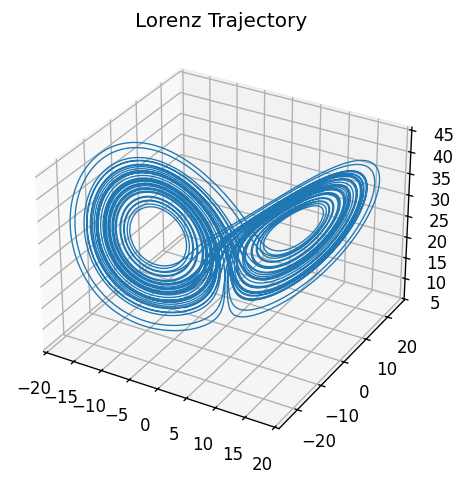

In [77]:
# Lorenz system parameters
beta = 8/3
sigma = 10
rho = 28
x0 = (0, 1, 20)

def lorenz(x, t, sigma=sigma, beta=beta, rho=rho):
    x, y, z = x
    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z,
    ]

# Generate data
DT = 0.001
t = np.arange(0, 50 + DT, DT)
X = integrate.odeint(lorenz, x0, t, rtol=1e-12, atol=1e-12*np.ones(3))

x, y, z = X.T
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, linewidth=0.8)
ax.set_title('Lorenz Trajectory')
plt.tight_layout()
plt.show()


In [78]:
# SINDy model: polynomial library up to 3rd order + STLSQ sparsification
poly_lib = ps.PolynomialLibrary(degree=3)
opt = ps.STLSQ(threshold=0.025, alpha=0.0, normalize_columns=True)

model = ps.SINDy(feature_library=poly_lib, optimizer=opt)
model.fit(X, t=DT)

print('Identified model:')
model.print()


Identified model:
(x0)' = -10.001 x0 +  10.001 x1
(x1)' =  28.005 x0 + -1.002 x1 + -1.000 x0 x2
(x2)' = -0.002 1 + -2.666 x2 +  1.001 x0 x1


In [ ]:
# Save the identified model text to a file for easy copy/paste
from io import StringIO
import sys
from pathlib import Path

buf = StringIO()
_stdout = sys.stdout
sys.stdout = buf
model.print()
sys.stdout = _stdout
model_text = buf.getvalue()

out_path = Path('Week4/outputs/lorenz_sindy_model.txt')
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(model_text)
print('Saved model to:', out_path)
print(model_text)

Saved model to: Week4/outputs/lorenz_sindy_model.txt
(x0)' = -10.001 x0 +  10.001 x1
(x1)' =  28.005 x0 + -1.002 x1 + -1.000 x0 x2
(x2)' = -0.002 1 + -2.666 x2 +  1.001 x0 x1



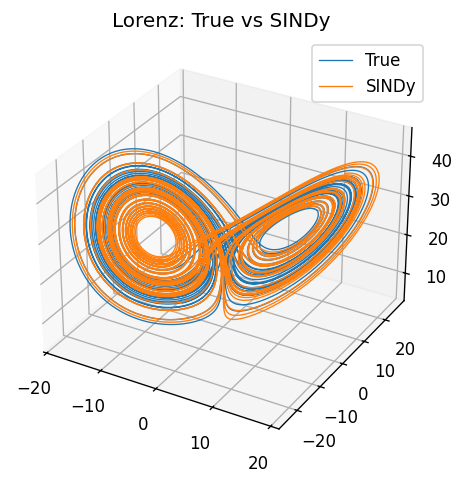

In [74]:
# Compare true vs. SINDy-predicted trajectory from same IC
X_sim = model.simulate(x0, t)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
ax.plot(X[:, 0], X[:, 1], X[:, 2], linewidth=0.8, label='True')
ax.plot(X_sim[:, 0], X_sim[:, 1], X_sim[:, 2], linewidth=0.8, label='SINDy')
ax.set_title('Lorenz: True vs SINDy')
ax.legend()
plt.tight_layout()
plt.show()


In [75]:
# Coefficient comparison (optional)
# You can inspect model.coefficients() for the discovered terms
coeffs = model.coefficients()
feature_names = model.get_feature_names()
print('Features:', feature_names)
print('Coefficients:\n', coeffs)


Features: ['1', 'x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2', 'x2^2', 'x0^3', 'x0^2 x1', 'x0^2 x2', 'x0 x1^2', 'x0 x1 x2', 'x0 x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3']
Coefficients:
 [[ 0.00000000e+00 -1.00011466e+01  1.00006516e+01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  3.94418373e-05  0.00000000e+00
  -1.66651008e-05  0.00000000e+00  0.00000000e+00 -1.66658398e-06
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  2.80049725e+01 -1.00199953e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -1.00038355e+00  0.00000000e+00
   1.28580090e-04  0.00000000e+00 -1.03570562e-05  1.52933821e-05
   0.00000000e+00 -6.28090903e-06  0.00000000e+00  7.20064443e-06
  -6.52096734e-07  0.00000000e+00 -1.63965295e-06  0.00000000e+00]
 [-2.44717977e-03  0.00000000e+00  0.00000000e+00 -2.66602178e+00
  -2.17892962e-04  1.00054674e+00  0.00000000e+00 -1.77107637e-04
   0

# Exercise 7.5 — SINDy for the Rössler System (PySINDy)



## Problem Statement
Identify a SINDy model for the Rössler system using PySINDy (Book, Chapter 7, p. 308).

## Approach / Method
Describe data generation, library choice, sparsity settings, and validation procedure.

## Results
Provide the discovered model and trajectory comparisons.

## Discussion
Note deviations from the true system and possible causes (noise, library, thresholds).


# Exercise 7.7 — PDE‑FIND for the KdV Equation



## Problem Statement
Identify a PDE model for the KdV equation using PDE‑FIND (Book, Chapter 7, p. 308).

## Approach / Method
Describe data preparation, derivative estimation, candidate library, and sparsity selection.

## Results
Present the recovered PDE and quantitative/visual comparisons to the reference solution.

## Discussion
Discuss identifiability, noise sensitivity, and any regularization choices.


# Exercise X03.3 — Hidden Dynamics in Disease Spread



## Problem Statement
Recover hidden dynamics in a disease‑spread model. Specify the model class and the observable data used.

## Approach / Method
Describe the identification method (e.g., SINDy/least‑squares/NN), data preprocessing, and evaluation criteria.

## Results
Report the recovered dynamics and compare simulated trajectories with observed data.

## Discussion
Comment on model plausibility, identifiability, and limitations.


# Conclusion
Summarize the most important findings across the Week 4 exercises.
